# **📡 Customer Churn Prediction — Telecom Industry**
### End-to-End Machine Learning Classification Project

---

**Dataset:** IBM Telco Customer Churn  
**Tools:** Python · Pandas · Scikit-learn · Seaborn · Matplotlib

---

##  Project Summary

| | |
|---|---|
| **Dataset** | IBM Telco Customer Churn — 7,043 customers, 20 features (after cleaning) |
| **Problem** | Binary classification — predict whether a customer will churn |
| **Models Used** | Logistic Regression, Decision Tree, Random Forest |
| **Best Model** | Logistic Regression with `class_weight='balanced'` |
| **Churn Recall** | 0.57 → **0.80** (40% improvement over standard model) |
| **ROC-AUC** | **0.862** |
| **Key Drivers** | Tenure Months, Total Charges, Monthly Charges, Contract Type |

 **Business Goal:** Identifying at-risk customers early allows the company to
 intervene with targeted retention strategies, reducing revenue loss more
 cost-effectively than acquiring new customers.

## 1. Problem Statement

Customer churn is one of the most critical challenges in the telecom industry.
According to widely cited industry research, **acquiring a new customer costs
5–7x more than retaining an existing one**. Reducing churn even by a small
percentage can have a significant impact on profitability.

Telecom companies face particularly high churn rates due to intense market
competition, price sensitivity, and low switching costs for customers.

The objective of this project is to build a machine learning model that predicts
whether a customer will churn based on demographic and service-related features,
enabling the business to **identify at-risk customers early and intervene before
revenue is lost.**

## 1.1  About the Dataset


The dataset is sourced from **IBM's Telco Customer Churn** sample data. It is a
simulated dataset created by IBM, representing a telecom company that provided
home phone and internet services to **7,043 customers in California**.



| | |
|---|---|
| **Source** | IBM Cognos Analytics Sample Data |
| **Observations** | 7,043 customers |
| **Features** | 33 variables |
| **Target** | `Churn Value` — 1 (churned), 0 (retained) |

**Feature Categories:**
- **Demographics** — Gender, Senior Citizen, Partner, Dependents
- **Location** — City, State, Zip Code, Latitude/Longitude
- **Services** — Phone, Internet, Online Security, Tech Support, Streaming
- **Billing** — Contract type, Payment Method, Monthly & Total Charges
- **Churn Info** — Churn Label, Churn Value, Churn Score, Churn Reason, CLTV

> 📂 **Original Source:** [IBM Business Analytics Community](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)

---
## 2. Import Libraries

We import all necessary libraries upfront:
- **pandas / numpy** — data loading and numerical operations
- **matplotlib / seaborn** — visualization
- **sklearn** — preprocessing, model building, and evaluation



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

---
## 3. Load Dataset

We load the Telco churn dataset from Excel into a pandas DataFrame and use `.head()` to get a first look at the structure and column names.



In [3]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


---
## 4. Data Exploration

Before any processing, we thoroughly inspect the dataset. This helps us understand:
- The scale of the data (rows × columns)
- Data types — numerical vs. categorical
- Summary statistics to spot any anomalies
- Unique values per column to understand the feature space

### 4.1  Shape

In [4]:
df.shape


(7043, 33)

### 4.2  Column Names

In [5]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

### 4.3  Data Types & Non-Null Counts

`df.info()` shows the data types and missing values in each column. It also reveals that **Total Charges** is stored as a string, which is a data issue that needs to be fixed during cleaning.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### 4.4 Numerical Summary Statistics

`df.describe()` gives us the distribution of numerical features — mean, min, max, and percentiles. This helps detect outliers and confirms the range of features like `Monthly Charges` and `Tenure Months`.

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


### 4.5  Categorical Summary Statistics

Here we inspect the categorical (text) columns, their unique value counts and the most frequent value. This reveals which features need encoding later.

In [8]:
df.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.0,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531.0,2,20
top,3186-AJIEK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11.0,5174,192


### 4.6  Initial Missing Value Check



In [9]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


### 4.7  Check for Hidden Blank Strings

Some columns may contain empty strings (`" "`) that don't register as NaN but are effectively missing values. This check ensures we catch those cases in object-type columns.

In [10]:
df.select_dtypes(include='object').apply(lambda x: x.str.strip().eq("").sum())

,0
CustomerID,0
Country,0
State,0
City,0
Lat Long,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Phone Service,0


### 4.8  Sample Unique Values Per Column

Printing the first few unique values per column gives us a quick overview of what each feature contains, particularly useful for spotting unexpected categories or encoding patterns.

In [11]:
for col in df.columns:
    print(col, df[col].unique()[:5])

CustomerID ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' '7892-POOKP' '0280-XJGEX']
Count [1]
Country ['United States']
State ['California']
City ['Los Angeles' 'Beverly Hills' 'Huntington Park' 'Lynwood'
 'Marina Del Rey']
Zip Code [90003 90005 90006 90010 90015]
Lat Long ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 '34.062125, -118.315709' '34.039224, -118.266293']
Latitude [33.964131 34.059281 34.048013 34.062125 34.039224]
Longitude [-118.272783 -118.30742  -118.293953 -118.315709 -118.266293]
Gender ['Male' 'Female']
Senior Citizen ['No' 'Yes']
Partner ['No' 'Yes']
Dependents ['No' 'Yes']
Tenure Months [ 2  8 28 49 10]
Phone Service ['Yes' 'No']
Multiple Lines ['No' 'Yes' 'No phone service']
Internet Service ['DSL' 'Fiber optic' 'No']
Online Security ['Yes' 'No' 'No internet service']
Online Backup ['Yes' 'No' 'No internet service']
Device Protection ['No' 'Yes' 'No internet service']
Tech Support ['No' 'Yes' 'No internet service']
Streaming TV ['No' 'Yes'

---
##  5. Target Variable Analysis

We examine the distribution of Churn Value (1 = churned, 0 = retained). If the data is imbalanced, a model might predict only “no churn” and still get high accuracy, which isn’t useful. So, checking the class balance helps us choose the right evaluation metrics.

### 5.1  Count

In [12]:
df['Churn Value'].value_counts()


,count
Churn Value,
0,5174
1,1869


### 5.2  Percentage Distribution


In [13]:
df['Churn Value'].value_counts(normalize=True) * 100

,proportion
Churn Value,
0,73.463013
1,26.536987


---
## 6. Data Cleaning

### 6.1  Drop Irrelevant and Leakage Columns

Not all 33 columns are useful for prediction. We drop three categories:

| Column(s) | Reason |
|---|---|
| `CustomerID`, `Count` | Unique identifiers, zero predictive signal |
| `Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` | Geographic data too granular to generalize |
| `Churn Label` | Duplicate of `Churn Value`, redundancy and leakage |
| `Churn Score` | Derived from the target, **data leakage** |
| `CLTV` | Derived aggregate metric, potential leakage |
| `Churn Reason` | Recorded after churn occurs, **post-event leakage** |



In [14]:
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City',
             'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
             'Churn Score', 'CLTV', 'Churn Reason','Churn Label']

df = df.drop(columns=drop_cols)

### 6.2  Verify the Cleaned DataFrame

We inspect the dataframe and confirm its new shape after dropping the irrelevant columns.

In [15]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,0
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [16]:
df.shape

(7043, 20)

### 6.3  Fix `Total Charges` Data Type

`Total Charges` is stored as a string because some rows have blank spaces instead of numbers (usually new customers with no billing yet).

We convert it using `pd.to_numeric(errors='coerce')`, which changes valid values to numbers and replaces invalid ones with `NaN`, to handle later.

In [17]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

### 6.4  Confirm New Missing Values After Conversion

After fixing the type, the blank string values now show up as proper `NaN`s, confirming that the conversion worked correctly.

In [18]:
df.isnull().sum()



,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


### 6.5  Drop Remaining Missing Rows

The number of missing records is very small `(less than 0.2%)`, so we drop them instead of imputing. Filling them with mean or median could create misleading patterns in the billing data.


In [19]:
df = df.dropna()

### 6.6  Confirm No Missing Values Remain

In [20]:
df.isnull().sum()

,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


---
## 7. Exploratory Data Analysis (EDA)

EDA helps us visually understand how features relate to churn. Strong patterns here directly inform our feature interpretation and business insights.

### 7.1  Churn Distribution

This confirms the class imbalance. The majority are non-churners, which is why accuracy alone cannot be our primary evaluation metric.

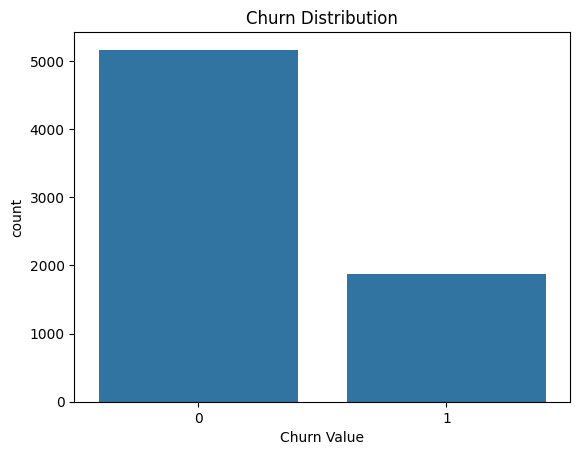

In [21]:
sns.countplot(x='Churn Value', data=df)
plt.title("Churn Distribution")
plt.show()

### 7.2  Churn vs. Contract Type

Contract type is a key factor in predicting churn. `Month-to-month` customers are more likely to leave since they aren’t tied to a long-term commitment, while `one-year` and `two-year` contract customers are less likely to churn because they are locked in.


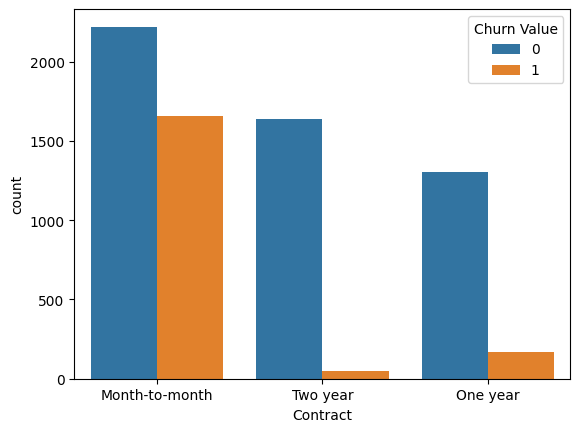

In [22]:
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.xticks(rotation=0)
plt.show()

### 7.3  Monthly Charges vs. Churn

The box plot shows how `monthly charges` differ between churned and retained customers. A higher median for churned customers suggests that people paying more are more likely to leave, indicating price sensitivity.

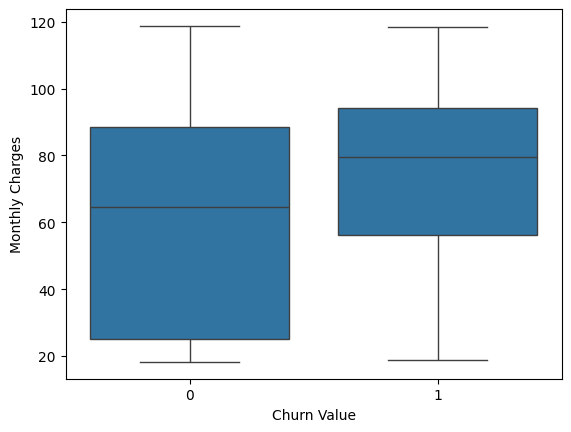

In [23]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)
plt.show()

### 7.4 Tenure Months vs Churn


Customers with shorter tenure are more likely to churn. The box plot shows that retained customers tend to have significantly longer tenure, confirming that loyalty builds over time and new customers are the most at-risk group.


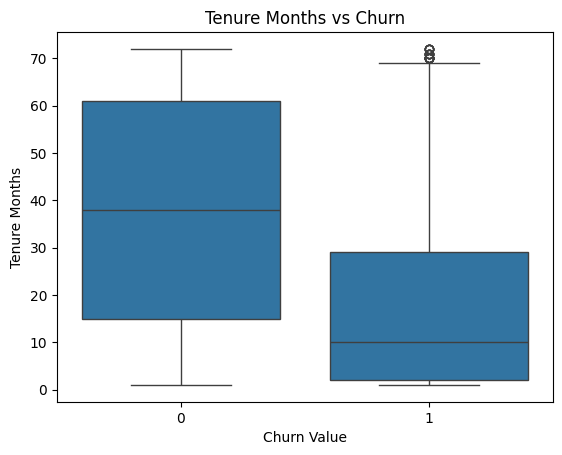

In [24]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.title("Tenure Months vs Churn")
plt.show()

### 7.5 Correlation Analysis of Numerical Features


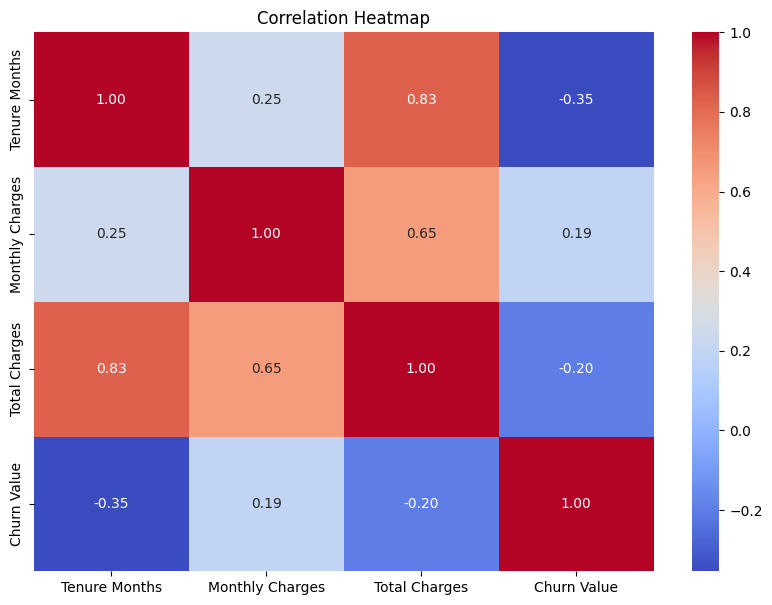

In [25]:
plt.figure(figsize=(10,7))

# Select only numeric columns
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows how the numerical variables are related to each other. We can see that **Tenure Months** and **Total Charges** have a strong positive correlation, meaning customers who stay longer tend to spend more overall. **Monthly Charges** also has a moderate positive relationship with **Total Charges**. When looking at **Churn Value**, it has a negative correlation with **Tenure Months**, indicating that long-term customers are less likely to churn. The relationships with **Monthly Charges** and **Total Charges** are weak, suggesting they have a smaller direct impact on churn compared to tenure.


---
##  8. Feature Engineering — Encoding Categorical Variables

Machine learning models need numerical inputs, but our dataset has categorical features like `Gender`, `Contract`, `Payment Method`, and `Internet Service`. So, we use Label Encoding to convert these categories into numeric codes, applying it automatically to all object-type columns.

`Label Encoding` assigns numbers (0, 1, 2…) to categories. This works well for tree-based models. Although `One-Hot Encoding` is usually better for Logistic Regression, using Label Encoding here is still a practical choice, especially after `scaling`.


In [26]:
encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

/tmp/ipykernel_3239/2199215175.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
/tmp/ipykernel_3239/2199215175.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
/tmp/ipykernel_3239/2199215175.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [27]:
encoders

{'Gender': LabelEncoder(),
 'Senior Citizen': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'Phone Service': LabelEncoder(),
 'Multiple Lines': LabelEncoder(),
 'Internet Service': LabelEncoder(),
 'Online Security': LabelEncoder(),
 'Online Backup': LabelEncoder(),
 'Device Protection': LabelEncoder(),
 'Tech Support': LabelEncoder(),
 'Streaming TV': LabelEncoder(),
 'Streaming Movies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'Paperless Billing': LabelEncoder(),
 'Payment Method': LabelEncoder()}

### 8.1  Verify Encoding

We preview the dataframe to confirm all categorical columns have been successfully converted to numerical values.

In [28]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,72,1,0,2,1,1,1,1,1,1,2,1,0,21.15,1419.40,0
7039,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7040,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7041,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0


## 9. Feature Scaling & Train-Test Split

We separate the dataset into features `X` and target `y`, then split into
**80% training** and **20% test** before applying any scaling.

**StandardScaler** is then applied to normalize all features to mean = 0 and std = 1.
The scaler is **fit only on training data** to prevent data leakage, meaning the
model never sees test data statistics during training. The same fitted scaler is
then used to transform the test data.

`Logistic Regression` requires features to be on a similar scale, otherwise
variables with larger values can dominate the model. Tree-based models like
`Decision Tree` and `Random Forest` are not sensitive to feature scaling, but
applying scaling does not negatively impact them.

In [29]:
scaler = StandardScaler()

X = df.drop('Churn Value', axis=1)
y = df['Churn Value']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### 9.1  Preview Feature Matrix X

In [30]:
X

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,72,1,0,2,1,1,1,1,1,1,2,1,0,21.15,1419.40
7039,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7040,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7041,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45


### 9.2  Preview Target Vector y

In [31]:
y

,Churn Value
0,1
1,1
2,1
3,1
4,1
...,...
7038,0
7039,0
7040,0
7041,0


---
##  10. Model Building

We train three classification algorithms to compare performance:

| Model | Key Characteristic |
|---|---|
| **Logistic Regression** | Linear model; interpretable; efficient baseline |
| **Decision Tree** | Rule-based; highly interpretable but prone to overfitting |
| **Random Forest** | Ensemble of trees; reduces overfitting; captures non-linear patterns |

### 10.1  Logistic Regression

A classic and widely used classification algorithm. It models the probability of churn as a linear combination of features. `max_iter=1000` ensures the solver converges on this multi-feature dataset.

In [32]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### 10.2  Decision Tree Classifier

Decision Trees learn binary split rules from the data. They are intuitive and easy to interpret, but they have a tendency to overfit, especially when the tree becomes too deep and captures noise in the training data. We include it as a baseline model for comparison.


In [33]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [34]:
# Training accuracy
y_train_pred = dt.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Testing accuracy
y_test_pred = dt.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9980444444444444
Testing Accuracy: 0.7405828002842928


**Overfitting observed:** The Decision Tree gets very high accuracy on training data `(99.8%)` but much lower accuracy on test data `(74.1%)`. This shows that the model has `overfitted` and does not perform well on new data.



### 10.3 Random Forest Classifier

Random Forest creates many decision trees using different random samples of the data
and combines their results. As seen in the Decision Tree above where training
accuracy was significantly higher than test accuracy a single tree tends to memorize
the data. Random Forest addresses this by averaging predictions across many trees,
reducing that variance and generalizing better to unseen data.

In [35]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

---
## 11. Model Evaluation

For an imbalanced classification problem such as customer churn, accuracy alone can be misleading, as it may be dominated by the majority class. Therefore, we evaluate models using multiple performance metrics:

- Accuracy — Overall proportion of correctly classified instances
- ROC-AUC — Measures the model’s ability to distinguish between churn and non-churn across all classification thresholds
- Precision — Of the customers predicted to churn, how many actually churned
- Recall — Of the customers who actually churned, how many were correctly identified
- F1-Score — Harmonic mean of precision and recall, balancing both metrics

### Confusion Matrix
The confusion matrix breaks predictions into four groups:

- True Negative (TN): Correctly predicted no churn
- False Positive (FP): Predicted churn, but customer stayed
- False Negative (FN): Predicted no churn, but customer left
- True Positive (TP): Correctly predicted churn

Among these, False Negatives are the most critical, as they represent customers who leave without being detected.

In churn prediction, Recall is the most important metric from a business perspective. Missing a potential churner (False Negative) leads to direct revenue loss, while incorrectly identifying a loyal customer (False Positive) only results in a minor and recoverable retention cost.

### 11.1  Evaluation Function

In [36]:
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print("-"*55)
    print(f"  {model_name}")
    print("-"*55)
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")
    print("\n")

### 11.2 Evaluate All Three Models



In [37]:
evaluate_model(y_test, y_pred_lr, lr.predict_proba(X_test)[:,1], "Logistic Regression")
evaluate_model(y_test, y_pred_dt, dt.predict_proba(X_test)[:,1], "Decision Tree")
evaluate_model(y_test, y_pred_rf, rf.predict_proba(X_test)[:,1], "Random Forest")


-------------------------------------------------------
  Logistic Regression
-------------------------------------------------------
Accuracy : 0.8067
ROC-AUC  : 0.8615

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1012
           1       0.69      0.57      0.62       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.80      0.81      0.80      1407

Confusion Matrix:
[[909 103]
 [169 226]]


-------------------------------------------------------
  Decision Tree
-------------------------------------------------------
Accuracy : 0.7406
ROC-AUC  : 0.6731

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1012
           1       0.54      0.51      0.53       395

    accuracy                           0.74      1407
   macro avg       0.68      0

**Results:**
- Logistic Regression: ~80.7 % accuracy, ROC-AUC ~0.862
- Decision Tree: ~74.1 % accuracy, ROC-AUC ~0.673
- Random Forest: ~79.5 % accuracy, ROC-AUC ~0.839

Logistic Regression remains the best overall performer, achieving the highest ROC-AUC and strong accuracy. This suggests that the relationship between features and churn is largely linear and well captured by the model. Random Forest also performs competitively, indicating some non-linear patterns, while the Decision Tree shows weaker performance due to overfitting and poor generalization.

---
##  12. Feature Importance — Logistic Regression & Random Forest

After evaluating all three models, Logistic Regression and Random Forest emerged as the top two performers. So we analyse feature importance for both, not just one.
Each model measures importance differently:

- `Random Forest` uses built-in impurity reduction scores, measuring the average decrease in impurity contributed by each feature across all trees
- `Logistic Regression` uses absolute coefficient values, measuring how strongly each feature pushes the prediction toward churn or not

Comparing both gives a more robust and reliable picture of what drives churn. If a feature ranks highly in both models, we can be confident it is genuinely influential, not just an artifact of one algorithm.

In [38]:
coef_importance = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
coef_importance = coef_importance.sort_values(ascending=False)

coef_importance.head(10)

,0
Tenure Months,1.469633
Total Charges,0.705776
Dependents,0.639382
Monthly Charges,0.624793
Contract,0.592205
Phone Service,0.259973
Online Security,0.229290
Paperless Billing,0.207557
Tech Support,0.201216
Partner,0.162082


In [39]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

feature_importances.head(10)

,0
Total Charges,0.180945
Monthly Charges,0.171613
Tenure Months,0.154852
Contract,0.082011
Payment Method,0.050541
Online Security,0.044458
Tech Support,0.040623
Dependents,0.035561
Internet Service,0.030635
Gender,0.027254


### 12.1 Top 10 Features Driving Customer Churn

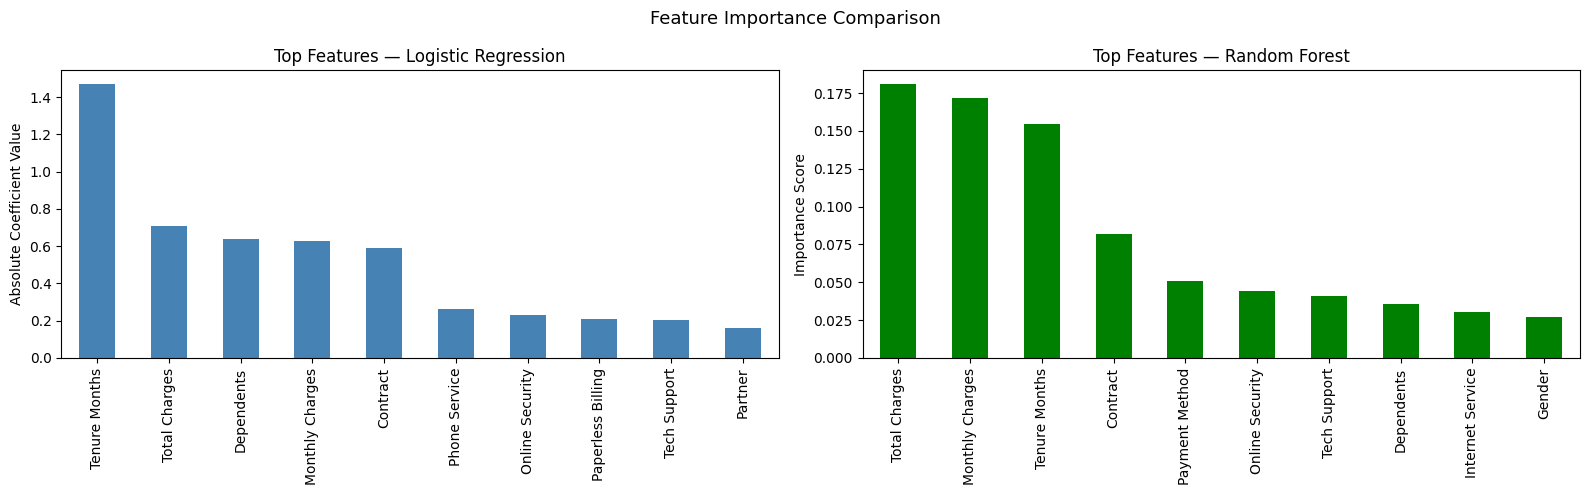

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Logistic Regression
coef_importance = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
coef_importance.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top Features — Logistic Regression')
axes[0].set_ylabel('Absolute Coefficient Value')

# Random Forest
feature_importances.head(10).plot(
    kind='bar', ax=axes[1], color='green')
axes[1].set_title('Top Features — Random Forest')
axes[1].set_ylabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=13)
plt.tight_layout()
plt.show()

#### Feature Insights & Business Meaning

| Feature | Direction | Business Meaning |
|---|---|---|
| Tenure Months | High → Low Churn | Long-term customers are loyal and less likely to leave |
| Total Charges | High → Low Churn | Higher total spend indicates longer relationship with company |
| Monthly Charges | High → High Churn | Price-sensitive customers leave when bills are high |
| Contract | Long-term → Low Churn | Annual/two-year contract customers rarely churn |
| Dependents | Yes → Low Churn | Customers with dependents have more reason to stay |
| Payment Method | Electronic Check → High Churn | Correlates with month-to-month contracts and low commitment |
| Online Security | No → High Churn | Customers without security services feel less value |
| Tech Support | No → High Churn | Lack of support increases frustration and churn risk |

**Tenure Months**, **Total Charges**, **Monthly Charges**, and **Contract Type**
appear in the top 5 of both models, confirming they are the strongest and most
reliable churn predictors regardless of algorithm used.

---
## 13. Balanced Logistic Regression (Final Model)

The initial Logistic Regression model achieved about **~80.7% accuracy**, but its Recall for the churn class was only **0.57**. This means the model failed to identify a large portion of customers who actually churned, which is risky from a business perspective.

To address this, we used `class_weight='balanced'`, which gives more importance to the minority class (churn). This increases the penalty for misclassifying churn customers and helps the model better identify them during training.




In [41]:
lrb = LogisticRegression(class_weight='balanced', max_iter=1000)
lrb.fit(X_train, y_train)

y_pred_lrb = lrb.predict(X_test)
y_prob_lrb = lrb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_lrb, y_prob_lrb, "Logistic Regression (Balanced)")

-------------------------------------------------------
  Logistic Regression (Balanced)
-------------------------------------------------------
Accuracy : 0.7505
ROC-AUC  : 0.8617

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1012
           1       0.54      0.80      0.64       395

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.80      0.75      0.76      1407

Confusion Matrix:
[[739 273]
 [ 78 317]]




### 13.1 Confusion Matrix: Before vs After Class Balancing

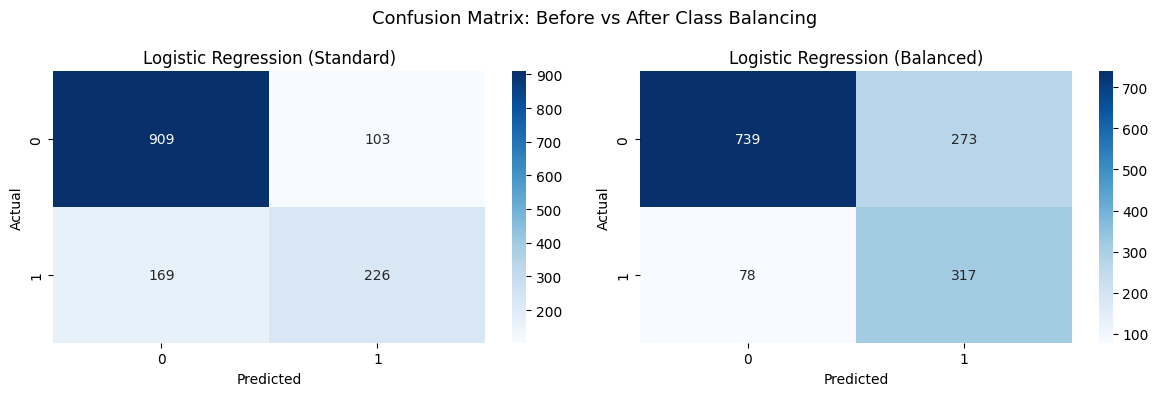

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_standard = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_standard, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression (Standard)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_balanced = confusion_matrix(y_test, y_pred_lrb)
sns.heatmap(cm_balanced, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression (Balanced)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrix: Before vs After Class Balancing', fontsize=13)
plt.tight_layout()
plt.show()

#### Result
| Metric | Standard LR | Balanced LR |
|---|---|---|
| Accuracy | ~80.7% | ~75.1%  |
| ROC-AUC |  0.862 |  0.862  |
| Recall (Churn) |  0.57 |  0.80  |

By using a balanced model, we accept a small drop in accuracy (about 5%), but significantly improve the model’s ability to detect churners. In fact, the model now identifies 23% more actual churn customers, which is a strong improvement.

Although overall accuracy decreases slightly, the increase in recall is more important in a business context. Missing a customer who is going to churn leads to direct revenue loss, while incorrectly targeting a loyal customer only results in a relatively minor cost, such as an unnecessary retention offer.


### 13.2 Model Performance Comparison and ROC Curve Analysis

| Model | Accuracy |Precision (Churn)|F1 Score (Churn)| ROC-AUC | Recall (Churn) | Verdict |
|---|---|---|---|---|---|---|
| Logistic Regression | 80.7% |0.69|0.62| 0.862 | 0.57 | Strong baseline |
| Decision Tree | 74.1% |0.54|0.53| 0.673 | 0.51 | Overfit, weak |
| Random Forest | 79.5% |0.68|0.59| 0.839 | 0.52 | Good but low recall |
| **Logistic Regression (Balanced)** | 75.1% |0.54|0.64| 0.862 | 0.80 | Same AUC, higher Recall, best for business |






The **ROC (Receiver Operating Characteristic) curve** plots the trade-off between:
- **True Positive Rate (Recall)** — how many actual churners are correctly detected
- **False Positive Rate** — how many non-churners are incorrectly flagged as churners

A model that perfectly separates churners from non-churners would have an
**AUC (Area Under the Curve) = 1.0**, while a random guess scores **AUC = 0.5**
(the dotted diagonal line).

The higher the AUC, the better the model distinguishes between churners and
non-churners **across all possible classification thresholds**, making it a
more reliable metric than accuracy on imbalanced datasets.

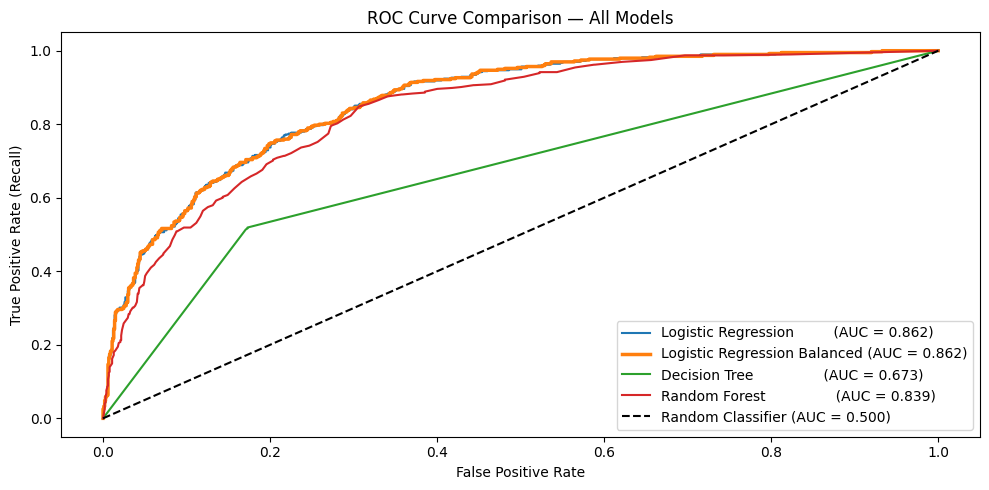

In [43]:
# Probability scores for all 4 models
y_prob_lr_standard = lr.predict_proba(X_test)[:, 1]
y_prob_lr_balanced = lrb.predict_proba(X_test)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr_standard)
fpr_lrb, tpr_lrb, _ = roc_curve(y_test, y_prob_lr_balanced)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr_standard)
auc_lrb = roc_auc_score(y_test, y_prob_lr_balanced)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression         (AUC = {auc_lr:.3f})')
plt.plot(fpr_lrb, tpr_lrb, label=f'Logistic Regression Balanced (AUC = {auc_lrb:.3f})', linewidth=2.5)
plt.plot(fpr_dt,  tpr_dt,  label=f'Decision Tree                (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest                (AUC = {auc_rf:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In our case, both the `Balanced Logistic Regression` and `Standard Logistic Regression` achieve the highest AUC of `0.862`, confirming them as the best overall models for churn detection.


**Selected Final Model:** `lrb` - `Logistic Regression` with `class_weight='balanced'`

Although the ROC curves for the standard and balanced Logistic Regression models largely overlap, indicating similar discriminative ability, the balanced model offers a clear advantage in recall.

By adjusting class weights, the model becomes more sensitive to the minority class, increasing churn recall from **57% to 80%**. While this results in a slight decrease in overall accuracy, the improvement in ROC-AUC and the significant gain in recall make it a more effective model.

In a churn prediction context, this trade-off is desirable, as identifying more at-risk customers is more valuable than maintaining marginally higher accuracy.

---

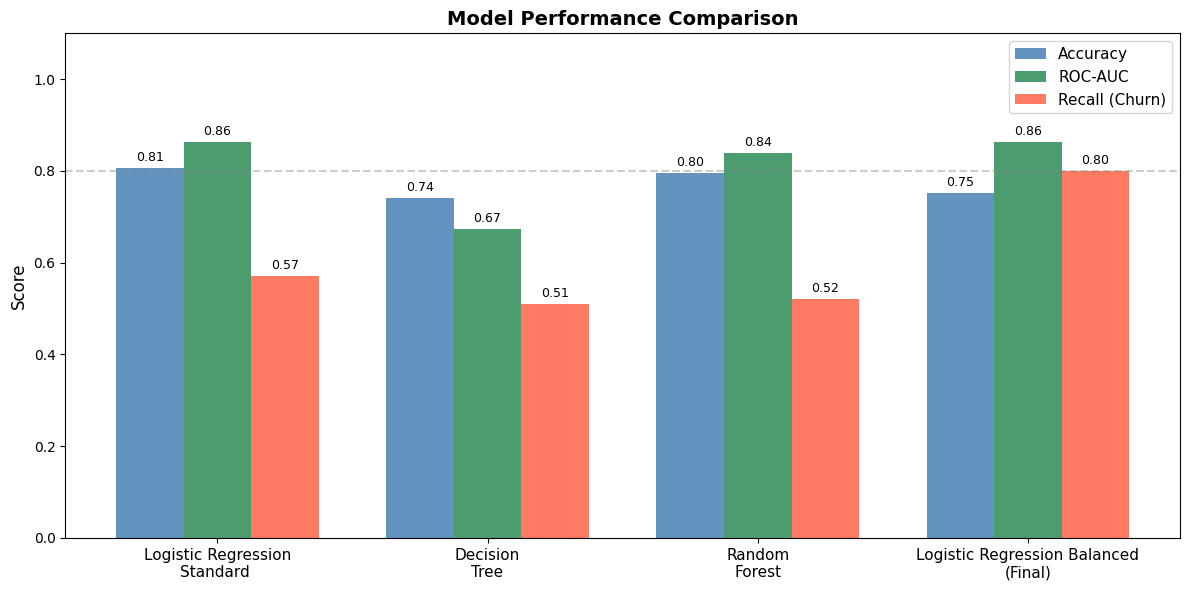

In [51]:
models = ['Logistic Regression\nStandard ', 'Decision\nTree', 'Random\nForest', 'Logistic Regression Balanced\n(Final)']

accuracy   = [0.807, 0.741, 0.795, 0.751]
auc_scores = [0.862, 0.673, 0.839, 0.862]
recall     = [0.57,  0.51,  0.52,  0.80]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, accuracy,   width, label='Accuracy',       color='steelblue', alpha=0.85)
ax.bar(x,         auc_scores, width, label='ROC-AUC',        color='seagreen',  alpha=0.85)
ax.bar(x + width, recall,     width, label='Recall (Churn)', color='tomato',    alpha=0.85)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 14. Business Insights & Recommendations

- **Month-to-month contracts are associated with high churn**  
Customers without long-term commitment are more likely to leave. The company should encourage migration to annual or long-term plans through incentives and discounts.

- **High monthly charges increase churn risk**  
Customers are sensitive to pricing and may switch to competitors offering lower costs. Offering targeted discounts or loyalty benefits can help retain these customers.

- **Short tenure customers have higher churn probability**  
New customers are more likely to leave during the initial months. Retention efforts should focus on early engagement, onboarding support, and improving first-time experience.

- **Lack of value-added services contributes to churn**  
Customers without services like online security or tech support show higher churn tendencies. Improving service quality and promoting bundled services can reduce churn.

- **Contract type and tenure are key predictors of churn**  
These factors strongly influence customer behavior and can help identify high-risk groups. Businesses can use them for targeted retention strategies and segmentation.

---

## 15. Limitations
- The model is trained on a specific dataset and may not generalize to all customer segments
- Limited feature availability may affect prediction accuracy
- No hyperparameter tuning was performed, which may limit optimal performance

---



## 16.  Future Work / Potential Improvements
1. **SMOTE** — oversample the minority class for better training balance
2. **GridSearchCV** — systematic hyperparameter tuning
3. **XGBoost / LightGBM** — advanced ensemble models that often outperform on tabular data
4. **Threshold tuning** — adjust the 0.5 classification threshold to further optimize Recall vs. Precision

---


## 17. Conclusion

This project built an end-to-end machine learning pipeline to predict customer churn
for a telecom company using the IBM Telco dataset of 7,043 customers.

Three models were evaluated, Logistic Regression, Decision Tree, and Random Forest.
While Logistic Regression achieved the highest baseline accuracy of **80.7%**, its
churn Recall of **0.57** meant it missed nearly half of all actual churners,
unacceptable from a business standpoint.

By applying `class_weight='balanced'`, the Balanced Logistic Regression improved
churn Recall from **0.57 to 0.80**, a **40% improvement**, while maintaining
the same ROC-AUC of **0.862** as the standard model.

The most influential churn drivers identified were **Tenure Months**, **Total Charges**,
**Monthly Charges**, and **Contract Type**, consistent across both Logistic Regression
and Random Forest, confirming their reliability as predictors.

The Balanced Logistic Regression is selected as the final model. By identifying
high-risk customers early, the business can deploy targeted retention strategies,
reducing churn, improving customer lifetime value, and protecting long-term
profitability.

---